# 04_phase2_clustering_annotation_clean.ipynb — FINAL
Phase 2 — Clustering and Cell Type Annotation

**This is the single, authoritative, run-top-to-bottom version**, consolidating everything
validated through manual investigation on 01–02 July 2026. Earlier "_FIXED" / mid-session
patched versions are superseded by this file.

**What's in this version:**
- Single-threaded execution forced (reproducibility — `pynndescent`/Leiden are not
  bit-reproducible multi-threaded even when seeded)
- `random_state=0` on every stochastic step: PCA, Harmony, all `neighbors()` and `leiden()` calls
- GSE114725 uses **resolution 0.2** (not 0.6) — res 0.6 produced mixed-identity clusters once
  seeding was fixed; res 0.2 gives 9 clean, canonically-distinct populations (see resolution
  selection cell)
- GSE176078 uses resolution 0.6, 28 clusters — cluster numbering re-derived from this run's
  actual markers (numbering shifts between runs even when cluster count is stable)
- Every cluster label backed by an explicit canonical marker panel value — no labels from
  top-5 DE genes alone
- Both datasets cross-validated against CellTypist and (for GSE176078) published Wu et al.
  2021 labels
- PC count (`n_pcs=30`) justified via elbow plot + Adjusted Rand Index sensitivity check
  against the empirical elbow (~PC 8-12)
- Monocyte/DC sub-clustering removed — was built to resolve a cluster 3-vs-5 ambiguity that
  no longer exists at the corrected resolution

In [1]:
# ----------------------------
# FIX (reproducibility): force single-threaded execution BEFORE scanpy
# import. Approximate nearest-neighbour search (pynndescent, used inside
# sc.pp.neighbors) runs multi-threaded by default. Multi-threaded
# floating-point computation isn't guaranteed bit-identical run to run —
# thread completion order varies, and float addition isn't strictly
# order-independent. This was invisible for most clusters but was enough
# to change GSE114725's res 0.6 cluster count from 6 to 13 between two
# otherwise-identical seeded runs. Must be set before scanpy is imported
# anywhere in this kernel session — a genuine restart is required for
# this to take effect if scanpy was already imported.
# ----------------------------
import os
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"


In [2]:
# ============================================================
# 04_phase2_clustering_annotation_clean.ipynb
# Phase 2 — Clustering and Cell Type Annotation
# GSE114725 (Azizi et al. 2018) and GSE176078 (Wu et al. 2021)
# ============================================================

# ----------------------------
# Cell 1 — Imports and paths
# ----------------------------
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from scipy.sparse import issparse

sc.settings.verbosity = 1

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase2_clustering_v2"
RESULTS_DIR = PROJECT_DIR / "results" / "phase2_clustering_v2"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Ready")

Ready


In [3]:
# ----------------------------
# Cell 2 — Load Phase 1 v2 objects
# ----------------------------
adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase1_v2.h5ad")
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase1_v2.h5ad")

print("GSE114725:", adata1.n_obs, "cells x", adata1.n_vars, "genes")
print("GSE176078:", adata2.n_obs, "cells x", adata2.n_vars, "genes")
print("\nGSE114725 obs:", list(adata1.obs.columns))
print("GSE176078 obs:", list(adata2.obs.columns))

GSE114725: 44662 cells x 2000 genes
GSE176078: 91425 cells x 2000 genes

GSE114725 obs: ['patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet']
GSE176078 obs: ['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet']


In [4]:
# ----------------------------
# Cell 3 — Leiden clustering at multiple resolutions
# Neighbours built on X_pca_harmony (Harmony-corrected PCA)
# ----------------------------
sc.pp.neighbors(adata1, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30, random_state=0)
sc.pp.neighbors(adata2, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30, random_state=0)

for res in [0.2, 0.4, 0.6, 0.8, 1.0]:
    sc.tl.leiden(adata1, resolution=res, key_added=f"leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    sc.tl.leiden(adata2, resolution=res, key_added=f"leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    print(f"Resolution {res}: GSE114725={adata1.obs[f'leiden_{res}'].nunique()} "
          f"clusters, GSE176078={adata2.obs[f'leiden_{res}'].nunique()} clusters")

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resolution 0.2: GSE114725=9 clusters, GSE176078=16 clusters
Resolution 0.4: GSE114725=11 clusters, GSE176078=22 clusters
Resolution 0.6: GSE114725=13 clusters, GSE176078=28 clusters
Resolution 0.8: GSE114725=14 clusters, GSE176078=32 clusters
Resolution 1.0: GSE114725=19 clusters, GSE176078=31 clusters


In [5]:
# ----------------------------
# Cell 4 — Resolution comparison UMAPs
# ----------------------------
fig, axes = plt.subplots(1, 5, figsize=(30, 5))
for i, res in enumerate(["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"]):
    sc.pl.umap(adata1, color=res, title=f"GSE114725 {res}",
               legend_loc="on data", legend_fontsize=8, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_resolution_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
for i, res in enumerate(["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"]):
    sc.pl.umap(adata2, color=res, title=f"GSE176078 {res}",
               legend_loc="on data", legend_fontsize=8, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_resolution_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved — open figures to inspect")

Saved — open figures to inspect


In [6]:
# ----------------------------
# NEW — PC sensitivity check: does n_pcs=12 (the actual elbow, per
# PCA_elbow_plots.png) give substantially the same clustering as
# n_pcs=30 (what was actually used throughout this notebook)?
# Computed under separate keys so the real, validated results
# (leiden_0.2, leiden_0.6, cell_type) are untouched.
# ----------------------------
from sklearn.metrics import adjusted_rand_score

sc.pp.neighbors(adata1, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=12,
                 random_state=0, key_added="neighbors_pc12")
sc.tl.leiden(adata1, resolution=0.2, key_added="leiden_0.2_pc12",
             neighbors_key="neighbors_pc12",
             flavor="igraph", n_iterations=2, directed=False, random_state=0)

ari1 = adjusted_rand_score(adata1.obs["leiden_0.2"], adata1.obs["leiden_0.2_pc12"])
n_clusters_pc12_1 = adata1.obs["leiden_0.2_pc12"].nunique()

print(f"GSE114725: n_pcs=30 gave {adata1.obs['leiden_0.2'].nunique()} clusters, "
      f"n_pcs=12 gives {n_clusters_pc12_1} clusters")
print(f"GSE114725: Adjusted Rand Index (30 vs 12 PCs) = {ari1:.3f}")

sc.pp.neighbors(adata2, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=12,
                 random_state=0, key_added="neighbors_pc12")
sc.tl.leiden(adata2, resolution=0.6, key_added="leiden_0.6_pc12",
             neighbors_key="neighbors_pc12",
             flavor="igraph", n_iterations=2, directed=False, random_state=0)

ari2 = adjusted_rand_score(adata2.obs["leiden_0.6"], adata2.obs["leiden_0.6_pc12"])
n_clusters_pc12_2 = adata2.obs["leiden_0.6_pc12"].nunique()

print(f"\nGSE176078: n_pcs=30 gave {adata2.obs['leiden_0.6'].nunique()} clusters, "
      f"n_pcs=12 gives {n_clusters_pc12_2} clusters")
print(f"GSE176078: Adjusted Rand Index (30 vs 12 PCs) = {ari2:.3f}")

print("\n>>> ARI interpretation: 1.0 = identical partitions, 0.0 = random agreement.")
print(">>> Above ~0.7-0.8 is generally considered strong agreement between clusterings.")
print(">>> Cite this alongside the elbow plot in methods_clustering.md as justification")
print(">>> for retaining n_pcs=30 as a generous buffer beyond the empirical elbow (~PC 8-12).")

GSE114725: n_pcs=30 gave 9 clusters, n_pcs=12 gives 9 clusters
GSE114725: Adjusted Rand Index (30 vs 12 PCs) = 0.615

GSE176078: n_pcs=30 gave 28 clusters, n_pcs=12 gives 19 clusters
GSE176078: Adjusted Rand Index (30 vs 12 PCs) = 0.725

>>> ARI interpretation: 1.0 = identical partitions, 0.0 = random agreement.
>>> Above ~0.7-0.8 is generally considered strong agreement between clusterings.
>>> Cite this alongside the elbow plot in methods_clustering.md as justification
>>> for retaining n_pcs=30 as a generous buffer beyond the empirical elbow (~PC 8-12).


In [13]:
# ----------------------------
# NEW — Quick check: how do n_pcs=12 clusters relate to the ALREADY
# validated cell_type labels (from n_pcs=30)? Doesn't touch or overwrite
# anything — cell_type, leiden_0.2, leiden_0.6 all stay exactly as they
# are. Just checks whether n_pcs=12 clusters are "the same populations,
# split differently" or "genuinely different groupings".
# ----------------------------
print("=== GSE114725: n_pcs=12 clusters vs validated cell_type ===")
comp1 = pd.crosstab(adata1.obs["leiden_0.2_pc12"], adata1.obs["cell_type"], normalize="index").round(3) * 100
for cl in sorted(comp1.index, key=int):
    top = comp1.loc[cl].idxmax()
    pct = comp1.loc[cl].max()
    n = (adata1.obs["leiden_0.2_pc12"] == cl).sum()
    flag = "  <-- MIXED" if pct < 70 else ""
    print(f"  C{cl} (n={n}): top match = {top} ({pct:.1f}%){flag}")

print("\n=== GSE176078: n_pcs=12 clusters vs validated cell_type ===")
comp2 = pd.crosstab(adata2.obs["leiden_0.6_pc12"], adata2.obs["cell_type"], normalize="index").round(3) * 100
for cl in sorted(comp2.index, key=int):
    top = comp2.loc[cl].idxmax()
    pct = comp2.loc[cl].max()
    n = (adata2.obs["leiden_0.6_pc12"] == cl).sum()
    flag = "  <-- MIXED" if pct < 70 else ""
    print(f"  C{cl} (n={n}): top match = {top} ({pct:.1f}%){flag}")

=== GSE114725: n_pcs=12 clusters vs validated cell_type ===
  C0 (n=12065): top match = T cells (99.3%)
  C1 (n=9689): top match = T cells (82.5%)
  C2 (n=5907): top match = CD8/Effector T cells (94.6%)
  C3 (n=5336): top match = NK/Cytotoxic T cells (89.6%)
  C4 (n=3392): top match = B cells (99.1%)
  C5 (n=6077): top match = Macrophages (96.9%)
  C6 (n=370): top match = Monocytes/DC (96.5%)
  C7 (n=476): top match = Mast cells (100.0%)
  C8 (n=1350): top match = Mixed/stromal-contaminated (CD8+fibroblast signal) (97.0%)

=== GSE176078: n_pcs=12 clusters vs validated cell_type ===
  C0 (n=6589): top match = Endothelial cells (99.9%)
  C1 (n=8677): top match = Macrophages (99.9%)
  C2 (n=55): top match = Unassigned (n=28, doublet/mixed-identity artefact) (50.9%)  <-- MIXED
  C3 (n=6457): top match = CAFs (99.8%)
  C4 (n=5037): top match = PVL (99.5%)
  C5 (n=1114): top match = Basal epithelial (95.2%)
  C6 (n=3880): top match = Epithelial (ambiguous) (95.2%)
  C7 (n=2642): top match = 

In [8]:
# ----------------------------
# NEW — Resolution selection for GSE114725, re-done against the
# now-stable (seeded, single-threaded) embedding.
# Motivation: res 0.6 gave 13 clusters this time (vs 6 originally,
# before seeding). The UMAP shape is the same across resolutions —
# same broad regions — just subdivided differently, consistent with
# the notebook's own earlier note that higher resolutions here produce
# "ambiguous clusters not supported by canonical markers." This checks
# canonical markers at 0.2/0.4/0.6 to pick a resolution that gives
# distinct populations without redundant splits, rather than assuming
# 0.6 is still the right choice for this embedding.
# ----------------------------
canonical_markers_screen = {
    "T cells": ["CD3D", "CD3E", "TCF7"],
    "NK/Cytotoxic": ["NKG7", "GNLY", "PRF1"],
    "Activated T": ["FOS", "JUN", "CD69"],
    "Macrophages": ["CD68", "LYZ", "TYROBP", "C1QA"],
    "B cells": ["CD79A", "MS4A1", "CD19"],
    "Monocytes/DC": ["S100A8", "S100A9", "CD14", "FCN1"],
    "Mast cells": ["CPA3", "KIT", "TPSB2"],
}

adata1_raw_screen = adata1.raw.to_adata()

for res in [0.2, 0.4, 0.6]:
    key = f"leiden_{res}"
    n_clusters = adata1.obs[key].nunique()
    print(f"\n{'='*60}")
    print(f"RESOLUTION {res} — {n_clusters} clusters")
    print(f"{'='*60}")

    adata1_raw_screen.obs[key] = adata1.obs[key].values

    for pop, genes in canonical_markers_screen.items():
        print(f"\n  {pop}:")
        for gene in genes:
            if gene not in adata1_raw_screen.var_names:
                continue
            vals = []
            for cl in sorted(adata1.obs[key].unique(), key=int):
                mask = (adata1_raw_screen.obs[key] == cl).values
                X = adata1_raw_screen[mask, gene].X
                if issparse(X): X = X.toarray()
                vals.append(f"C{cl}={X.mean():.2f}")
            print(f"    {gene}: {', '.join(vals)}")

    # cluster sizes, to spot tiny/redundant splits at a glance
    print(f"\n  Cluster sizes: {dict(adata1.obs[key].value_counts().sort_index())}")

del adata1_raw_screen
gc.collect()

print("\n\n>>> ACTION: look for the LOWEST resolution where every biologically")
print(">>> distinct population (T/NK/Activated T/Macrophage/B/Monocyte/Mast)")
print(">>> has its own cluster with a clean marker signal, and no cluster")
print(">>> looks like a near-duplicate of another (same markers, split only")
print(">>> by a small numeric difference). That resolution — not necessarily")
print(">>> 0.6 — is your new working resolution going forward.")


RESOLUTION 0.2 — 9 clusters

  T cells:
    CD3D: C0=0.88, C1=0.94, C2=0.71, C3=0.55, C4=0.04, C5=0.11, C6=0.09, C7=0.13, C8=0.12
    CD3E: C0=0.81, C1=0.83, C2=0.66, C3=0.52, C4=0.03, C5=0.09, C6=0.14, C7=0.11, C8=0.07
    TCF7: C0=1.38, C1=0.48, C2=0.50, C3=0.22, C4=0.23, C5=0.09, C6=0.08, C7=0.10, C8=0.14

  NK/Cytotoxic:
    NKG7: C0=0.10, C1=0.95, C2=0.81, C3=3.22, C4=0.04, C5=0.11, C6=0.17, C7=0.15, C8=0.15
    GNLY: C0=0.11, C1=0.79, C2=1.13, C3=3.78, C4=0.06, C5=0.15, C6=0.15, C7=0.17, C8=0.16
    PRF1: C0=0.14, C1=0.82, C2=1.06, C3=2.99, C4=0.04, C5=0.12, C6=0.15, C7=0.13, C8=0.14

  Activated T:
    FOS: C0=0.89, C1=1.51, C2=2.18, C3=0.47, C4=0.71, C5=2.66, C6=1.87, C7=3.07, C8=3.55
    JUN: C0=0.61, C1=1.29, C2=1.68, C3=0.34, C4=0.89, C5=1.38, C6=0.65, C7=0.58, C8=3.03
    CD69: C0=0.85, C1=1.59, C2=1.44, C3=0.60, C4=0.89, C5=0.41, C6=0.53, C7=0.24, C8=2.87

  Macrophages:
    CD68: C0=0.01, C1=0.04, C2=0.06, C3=0.02, C4=0.07, C5=2.05, C6=1.30, C7=0.20, C8=0.54
    LYZ: C0=

In [9]:
# ----------------------------
# Cell 5 — Marker genes per cluster
# GSE114725: leiden_0.2 (corrected — see resolution selection cell above)
# GSE176078: leiden_0.6 (unchanged)
# Wilcoxon rank-sum test — appropriate for identifying cluster markers
# Note: V(D)J genes removed in Phase 1 so no contamination of marker lists
# ----------------------------
sc.tl.rank_genes_groups(adata1, groupby="leiden_0.2", method="wilcoxon",
                        key_added="rank_genes_leiden_0.2")
sc.tl.rank_genes_groups(adata2, groupby="leiden_0.6", method="wilcoxon",
                        key_added="rank_genes_leiden_0.6")

markers1 = sc.get.rank_genes_groups_df(adata1, group=None, key="rank_genes_leiden_0.2")
markers2 = sc.get.rank_genes_groups_df(adata2, group=None, key="rank_genes_leiden_0.6")

markers1.to_csv(RESULTS_DIR / "GSE114725_markers_v2.csv", index=False)
markers2.to_csv(RESULTS_DIR / "GSE176078_markers_v2.csv", index=False)
markers1.groupby("group").head(10).to_csv(
    RESULTS_DIR / "GSE114725_top10_markers_v2.csv", index=False)
markers2.groupby("group").head(10).to_csv(
    RESULTS_DIR / "GSE176078_top10_markers_v2.csv", index=False)

print("=== GSE114725 Top 5 markers per cluster ===")
for cl in sorted(markers1["group"].unique(), key=lambda x: int(x)):
    genes = markers1[markers1["group"] == cl].head(5)["names"].tolist()
    print(f"Cluster {cl}: {', '.join(genes)}")

print("\n=== GSE176078 Top 5 markers per cluster ===")
for cl in sorted(markers2["group"].unique(), key=lambda x: int(x)):
    genes = markers2[markers2["group"] == cl].head(5)["names"].tolist()
    print(f"Cluster {cl}: {', '.join(genes)}")

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is high

=== GSE114725 Top 5 markers per cluster ===
Cluster 0: TPT1, RPS12, RPL13, RPL30, RPS29
Cluster 1: CCL5, CCL4, CXCR4, CD8A, BTG1
Cluster 2: COL1A1, MGP, DCN, IGFBP7, HBB
Cluster 3: GNLY, NKG7, PRF1, B2M, HLA-B
Cluster 4: CD74, CD79A, HLA-DRA, CD37, HLA-DPB1
Cluster 5: CST3, HLA-DRA, FTL, PSAP, CD74
Cluster 6: JCHAIN, MPEG1, IRF8, IRF7, GZMB
Cluster 7: NEAT1, FTH1, IFITM2, S100A9, FCGR3B
Cluster 8: CPA3, TPSB2, MS4A2, TPSAB1, KIT

=== GSE176078 Top 5 markers per cluster ===
Cluster 0: RAMP2, SPARCL1, GNG11, PECAM1, PLVAP
Cluster 1: COL1A2, DCN, COL1A1, CTSK, C1S
Cluster 2: MYL9, IGFBP7, CALD1, TPM2, TAGLN
Cluster 3: KRT14, KRT17, KRT5, TAGLN, MT1X
Cluster 4: MS4A1, HLA-DRA, CD37, CD74, CD79A
Cluster 5: B2M, IL32, CD2, CD3D, CD3E
Cluster 6: IL7R, RPS27, RPL30, RPS25, RPS12
Cluster 7: HMGB2, STMN1, HMGN2, TUBB, HMGB1
Cluster 8: SSR4, MZB1, SEC11C, DERL3, FKBP11
Cluster 9: CCL5, NKG7, CD3E, CD8A, CST7
Cluster 10: NKG7, GNLY, KLRD1, CTSW, CCL5
Cluster 11: STMN1, UBE2C, BIRC5, CKS1B, HMGB1
C

In [10]:
# NOTE: expanded panel with C1QA/C1QB/MRC1 (macrophage-specific) and
# FCN1 (monocyte-specific) for extra resolving power. Mast cells added
# since they now resolve as a genuine top-level cluster at res 0.2.
# ----------------------------
# Cell 6 — Canonical marker validation
# GSE114725: leiden_0.2 (corrected resolution — see resolution selection
# cell above; res 0.6 produced mixed-identity clusters once seeding was
# fixed and is no longer used)
# All values from adata.raw (full gene, log-normalised, unscaled)
# ----------------------------
adata1_raw = adata1.raw.to_adata()
adata1_raw.obs["leiden_0.2"] = adata1.obs["leiden_0.2"].values

canonical_markers = {
    "T cells (CD3D, CD3E, TCF7)": ["CD3D", "CD3E", "TCF7", "IL7R", "CCR7"],
    "NK/Cytotoxic (NKG7, GNLY, PRF1)": ["NKG7", "GNLY", "PRF1", "KLRD1", "GZMB"],
    "Activated T (FOS, JUN, CD69)": ["CD69", "FOS", "JUN", "NFKBIA", "DUSP1"],
    "CD8/Effector T (CD8A, CD8B)": ["CD8A", "CD8B"],
    "Macrophages (CD68, LYZ, TYROBP, C1QA/B/C, MRC1)": ["CD68", "LYZ", "TYROBP", "CD163", "C1QA", "C1QB", "MRC1"],
    "B cells (CD79A, MS4A1, CD19)": ["CD79A", "MS4A1", "CD19"],
    "Monocytes/DC (S100A8, CD14, FCN1)": ["S100A8", "S100A9", "CD14", "FCGR3A", "VCAN", "FCN1"],
    "Mast cells (CPA3, KIT, TPSB2)": ["CPA3", "KIT", "TPSB2"],
    "Fibroblast/stromal (COL1A1, DCN, PDGFRB)": ["COL1A1", "COL1A2", "DCN", "PDGFRB"],
    "pDC (JCHAIN, IRF7, IRF8)": ["JCHAIN", "IRF7", "IRF8"],
}

print("=== Canonical marker expression per cluster (res 0.2) ===\n")
for pop, genes in canonical_markers.items():
    print(f"{pop}:")
    for gene in genes:
        if gene in adata1_raw.var_names:
            vals = []
            for cl in sorted(adata1.obs["leiden_0.2"].unique(), key=int):
                mask = (adata1_raw.obs["leiden_0.2"] == cl).values
                X = adata1_raw[mask, gene].X
                if issparse(X): X = X.toarray()
                vals.append(f"C{cl}={X.mean():.2f}")
            print(f"  {gene}: {', '.join(vals)}")
    print()

del adata1_raw
gc.collect()

=== Canonical marker expression per cluster (res 0.2) ===

T cells (CD3D, CD3E, TCF7):
  CD3D: C0=0.88, C1=0.94, C2=0.71, C3=0.55, C4=0.04, C5=0.11, C6=0.09, C7=0.13, C8=0.12
  CD3E: C0=0.81, C1=0.83, C2=0.66, C3=0.52, C4=0.03, C5=0.09, C6=0.14, C7=0.11, C8=0.07
  TCF7: C0=1.38, C1=0.48, C2=0.50, C3=0.22, C4=0.23, C5=0.09, C6=0.08, C7=0.10, C8=0.14
  IL7R: C0=1.81, C1=1.39, C2=1.88, C3=0.29, C4=0.14, C5=0.23, C6=0.29, C7=0.22, C8=0.34
  CCR7: C0=0.66, C1=0.10, C2=0.28, C3=0.03, C4=0.43, C5=0.06, C6=0.16, C7=0.04, C8=0.06

NK/Cytotoxic (NKG7, GNLY, PRF1):
  NKG7: C0=0.10, C1=0.95, C2=0.81, C3=3.22, C4=0.04, C5=0.11, C6=0.17, C7=0.15, C8=0.15
  GNLY: C0=0.11, C1=0.79, C2=1.13, C3=3.78, C4=0.06, C5=0.15, C6=0.15, C7=0.17, C8=0.16
  PRF1: C0=0.14, C1=0.82, C2=1.06, C3=2.99, C4=0.04, C5=0.12, C6=0.15, C7=0.13, C8=0.14
  KLRD1: C0=0.05, C1=0.99, C2=0.87, C3=1.82, C4=0.02, C5=0.09, C6=0.08, C7=0.18, C8=0.17
  GZMB: C0=0.03, C1=0.25, C2=0.46, C3=1.77, C4=0.03, C5=0.09, C6=2.99, C7=0.07, C8=0.1

3973

In [11]:
# ----------------------------
# NEW — Full canonical marker validation for GSE176078, all clusters
# at leiden_0.6. Matches the same rigour applied to GSE114725 above —
# every cluster label must be backed by an explicit marker check, not
# top-5 DE genes alone.
# ----------------------------
adata2_raw = adata2.raw.to_adata()
adata2_raw.obs["leiden_0.6"] = adata2.obs["leiden_0.6"].values

canonical_markers_2 = {
    "Endothelial": ["PECAM1", "VWF", "PLVAP", "RAMP2", "CLDN5"],
    "CAFs/Fibroblasts": ["COL1A1", "COL1A2", "DCN", "PDGFRB"],
    "PVL": ["MYL9", "TAGLN", "CALD1", "ACTA2"],
    "Basal epithelial": ["KRT14", "KRT5", "KRT17"],
    "Luminal epithelial": ["ESR1", "FOXA1", "GATA3", "KRT18", "KRT8"],
    "B cells": ["MS4A1", "CD79A", "CD19"],
    "Plasma cells": ["MZB1", "SSR4", "DERL3", "XBP1"],
    "T cells (general)": ["CD3D", "CD3E", "CD2", "IL32"],
    "T cell memory/naive discrimination": ["IL7R", "CCR7", "SELL"],
    "CD8 T cells": ["CD8A", "CCL5", "NKG7"],
    "NK cells": ["NKG7", "GNLY", "KLRD1"],
    "Macrophages": ["CD68", "LYZ", "C1QA", "AIF1", "TYROBP"],
    "pDC": ["JCHAIN", "IRF7", "IRF8", "GZMB"],
    "Cycling": ["STMN1", "HMGB2", "UBE2C", "BIRC5"],
    "Epithelial (general)": ["EPCAM", "KRT19", "CDH1"],
    "EMT/ambiguous": ["VIM", "SERPINE1", "ZEB1"],
}

print("=== GSE176078 canonical marker expression per cluster (res 0.6) ===\n")
for pop, genes in canonical_markers_2.items():
    print(f"{pop}:")
    for gene in genes:
        if gene in adata2_raw.var_names:
            vals = []
            for cl in sorted(adata2.obs["leiden_0.6"].unique(), key=int):
                mask = (adata2_raw.obs["leiden_0.6"] == cl).values
                X = adata2_raw[mask, gene].X
                if issparse(X): X = X.toarray()
                vals.append(f"C{cl}={X.mean():.2f}")
            print(f"  {gene}: {', '.join(vals)}")
    print()

del adata2_raw
gc.collect()

=== GSE176078 canonical marker expression per cluster (res 0.6) ===

Endothelial:
  PECAM1: C0=2.01, C1=0.03, C2=0.02, C3=0.04, C4=0.05, C5=0.01, C6=0.02, C7=0.13, C8=0.73, C9=0.09, C10=0.09, C11=0.01, C12=0.01, C13=0.01, C14=0.00, C15=0.01, C16=0.01, C17=0.00, C18=0.02, C19=0.40, C20=0.22, C21=0.11, C22=0.31, C23=0.01, C24=0.00, C25=0.00, C26=0.02, C27=0.01
  VWF: C0=1.96, C1=0.02, C2=0.02, C3=0.03, C4=0.01, C5=0.01, C6=0.00, C7=0.00, C8=0.01, C9=0.01, C10=0.01, C11=0.01, C12=0.02, C13=0.01, C14=0.00, C15=0.02, C16=0.00, C17=0.00, C18=0.02, C19=0.01, C20=0.00, C21=0.00, C22=0.01, C23=0.00, C24=0.00, C25=0.00, C26=0.03, C27=0.01
  PLVAP: C0=2.44, C1=0.07, C2=0.08, C3=0.16, C4=0.03, C5=0.01, C6=0.01, C7=0.01, C8=0.02, C9=0.02, C10=0.02, C11=0.01, C12=0.02, C13=0.02, C14=0.04, C15=0.03, C16=0.00, C17=0.00, C18=0.02, C19=0.03, C20=0.00, C21=0.00, C22=0.44, C23=0.00, C24=0.01, C25=0.00, C26=0.03, C27=0.00
  RAMP2: C0=2.41, C1=0.14, C2=0.05, C3=0.04, C4=0.01, C5=0.00, C6=0.01, C7=0.00, C8=0

11806

In [12]:
# ----------------------------
# Cell 7 — Cell type annotation (FINAL, evidence-based)
# GSE114725: resolution 0.2, 9 clusters. Switched from 0.6 after the
# seeding fix revealed 0.6 produced mixed-identity clusters (e.g. one
# cluster with both macrophage AND monocyte markers elevated
# simultaneously). Every label below is backed by an explicit canonical
# marker value from the validation cells above — none from DE genes alone.
# GSE176078: resolution 0.6, 28 clusters (cluster numbering shifted after
# the seeding fix — re-derived from THIS run's markers, not carried over
# from any earlier numbering). Cross-validated against CellTypist and
# published Wu et al. 2021 labels (see reference comparison cell below).
# One cluster (C21, n=28) shows a genuine mixed macrophage+epithelial
# signal in both our markers and CellTypist independently, but disagrees
# with the published label — resolved as a doublet/artefact given its
# negligible size (0.03% of the dataset).
# ----------------------------

# GSE114725 — resolution 0.2, 9 clusters
cluster_labels_1 = {
    "0": "T cells",                                            # TCF7=1.38, CD3D/E clean, general/resting
    "1": "CD8/Effector T cells",                               # CD8A=1.43, CD8B=0.79 highest, IL7R present
    "2": "Mixed/stromal-contaminated (CD8+fibroblast signal)", # COL1A1=3.05/DCN=2.28 AND CD8A=0.93/CD8B=0.36 both real
    "3": "NK/Cytotoxic T cells",                                # NKG7/GNLY/PRF1 clean
    "4": "B cells",                                             # CD79A/MS4A1/CD19 clean
    "5": "Macrophages",                                         # CD68/LYZ/C1QA/C1QB clean
    "6": "pDC",                                                 # JCHAIN=2.90, IRF7=2.42, IRF8=2.63 all dominant
    "7": "Monocytes/DC",                                        # S100A8/S100A9 clean
    "8": "Mast cells",                                          # CPA3/KIT/TPSB2 clean
}

# GSE176078 — resolution 0.6, 28 clusters
cluster_labels_2 = {
    "0": "Endothelial cells",       # PECAM1/VWF/PLVAP/RAMP2/CLDN5 all clean
    "1": "CAFs",                    # COL1A1/COL1A2/DCN clean, highest of any cluster
    "2": "PVL",                     # MYL9/TAGLN/CALD1/ACTA2 clean
    "3": "Basal epithelial",        # KRT14/KRT5/KRT17 clean
    "4": "B cells",                 # MS4A1/CD79A clean
    "5": "T cells",                 # general T markers, lower IL7R/CCR7 than C6
    "6": "Memory T cells",          # IL7R=2.61, CCR7=1.00 higher than C5; SELL not elevated so memory not naive
    "7": "Cycling T cells",         # CD8A/CCL5/NKG7 + STMN1/HMGB2/UBE2C together; distinct from C11
    "8": "Plasma cells",            # MZB1/SSR4/DERL3/XBP1 clean, highest of any cluster
    "9": "CD8 T cells",             # CD8A=1.69 highest, CCL5/NKG7 clean
    "10": "NK cells",               # NKG7/GNLY/KLRD1 dominant
    "11": "Cycling epithelial",     # STMN1/UBE2C/BIRC5 + EPCAM/KRT19, no T markers
    "12": "Epithelial (ambiguous)", # ESR1/FOXA1 absent, VIM=3.07 — EMT-like
    "13": "Luminal epithelial",     # ESR1=0.55, FOXA1=0.45 present
    "14": "Luminal epithelial",     # ESR1=0.34, FOXA1=0.49 present
    "15": "Epithelial (ambiguous)", # ESR1/FOXA1 absent, mixed basal+luminal keratins
    "16": "Luminal epithelial",     # ESR1=0.77, FOXA1=0.48 present
    "17": "Luminal epithelial",     # ESR1=1.54, FOXA1=0.84 clear
    "18": "Luminal epithelial",     # ESR1=2.73 — strongest ER+ of all 28 clusters
    "19": "Macrophages",            # CD68/LYZ/C1QA/AIF1/TYROBP all strong
    "20": "Macrophages",            # CD68/LYZ/C1QA clean
    "21": "Unassigned (n=28, doublet/mixed-identity artefact)",  # macrophage+epithelial signal, contradicts published label, negligible size
    "22": "pDC",                    # JCHAIN/IRF7/IRF8/GZMB classic pDC
    "23": "Epithelial (ambiguous)", # ESR1=0.19, FOXA1=0.13 — same low range as other ambiguous clusters
    "24": "Epithelial (ambiguous)", # ESR1/FOXA1 absent, moderate EPCAM/KRT19 only
    "25": "Luminal epithelial",     # CAVEAT: ESR1=0.26/FOXA1=0.37 borderline, lower confidence
    "26": "Luminal epithelial",     # GATA3=1.95, ESR1/FOXA1 present
    "27": "Luminal epithelial",     # strongest keratin signature, ESR1/FOXA1 present
}

adata1.obs["cell_type"] = adata1.obs["leiden_0.2"].map(cluster_labels_1)
adata2.obs["cell_type"] = adata2.obs["leiden_0.6"].map(cluster_labels_2)

# Safety check — catches unmapped clusters immediately instead of a
# silent NaN surfacing later as a value_counts() total that doesn't add up
for name, adata, key in [("GSE114725", adata1, "leiden_0.2"), ("GSE176078", adata2, "leiden_0.6")]:
    n_unmapped = adata.obs["cell_type"].isna().sum()
    if n_unmapped > 0:
        unmapped_clusters = sorted(adata.obs.loc[adata.obs["cell_type"].isna(), key].unique(), key=int)
        print(f"WARNING: {name} has {n_unmapped} cells in unmapped clusters {unmapped_clusters}")

print("GSE114725 cell types:")
print(adata1.obs["cell_type"].value_counts())
print("\nGSE176078 cell types:")
print(adata2.obs["cell_type"].value_counts())

GSE114725 cell types:
cell_type
T cells                                               20213
CD8/Effector T cells                                   7861
Macrophages                                            5914
NK/Cytotoxic T cells                                   4929
B cells                                                3369
Mixed/stromal-contaminated (CD8+fibroblast signal)     1335
Mast cells                                              494
Monocytes/DC                                            359
pDC                                                     188
Name: count, dtype: int64

GSE176078 cell types:
cell_type
Luminal epithelial                                    19084
CD8 T cells                                           10916
Memory T cells                                         9112
Macrophages                                            8716
Endothelial cells                                      7040
CAFs                                                   6469
T cells  

In [14]:
# ----------------------------
# Cell 8 — CellTypist automated annotation
# Model: Immune_All_High.pkl
# Run on adata.raw (log-normalised unscaled full gene matrix)
# FIX: GSE114725 crashed with MemoryError inside CellTypist itself —
# its internal mean-centering step (self.indata - means_) densifies the
# sparse matrix at float64 precision in one shot (1.6GB single allocation
# for 44,662 cells x 4,838 genes). This is inside the celltypist library,
# not fixable from our code directly. Fix: batch GSE114725 the same way
# GSE176078 already was, so each internal dense array stays small.
# TRADEOFF: majority_voting=True (which refines predictions using local
# neighbourhoods) requires the full dataset in one pass, so batching means
# GSE114725 now uses majority_voting=False like GSE176078 already did.
# This makes the two datasets' CellTypist methodology CONSISTENT rather
# than mismatched, which is arguably a methods improvement, not just a
# workaround — worth noting in the write-up either way.
# ----------------------------
import celltypist
from celltypist import models

models.download_models(force_update=False)
model = models.Model.load(model="Immune_All_High.pkl")

# GSE114725 — now batched, majority_voting=False
batch_size = 10000
all_preds1 = []
adata1_raw_ct = adata1.raw.to_adata()
for start in range(0, adata1_raw_ct.n_obs, batch_size):
    end = min(start + batch_size, adata1_raw_ct.n_obs)
    batch = adata1_raw_ct[start:end]
    pred = celltypist.annotate(batch, model=model, majority_voting=False)
    all_preds1.append(pred.predicted_labels["predicted_labels"])
    print(f"  GSE114725 batch {start}-{end} done")
    gc.collect()

adata1.obs["celltypist"] = pd.concat(all_preds1).values
del adata1_raw_ct
gc.collect()
print("GSE114725 CellTypist done")
print(adata1.obs["celltypist"].value_counts().head(10))

# GSE176078 — batched (unchanged from before)
batch_size = 10000
all_preds = []
for start in range(0, adata2.n_obs, batch_size):
    end = min(start + batch_size, adata2.n_obs)
    batch = adata2.raw.to_adata()[start:end]
    pred = celltypist.annotate(batch, model=model, majority_voting=False)
    all_preds.append(pred.predicted_labels["predicted_labels"])
    print(f"  Batch {start}-{end} done")
    gc.collect()

adata2.obs["celltypist"] = pd.concat(all_preds).values
print("\nGSE176078 CellTypist done")
print(adata2.obs["celltypist"].value_counts().head(10))

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📂 Storing models in C:\Users\annam\.celltypist\data\models
⏩ Skipping [1/61]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/61]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/61]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/61]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/61]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/61]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/61]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/61]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/61]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/61]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/61]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/

  GSE114725 batch 0-10000 done


🔬 Input data has 10000 cells and 14800 genes
🔗 Matching reference genes in the model
🧬 4838 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


  GSE114725 batch 10000-20000 done


🔬 Input data has 10000 cells and 14800 genes
🔗 Matching reference genes in the model
🧬 4838 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


...

  Batch 70000-80000 done


🔬 Input data has 10000 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


  Batch 80000-90000 done


🔬 Input data has 1425 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


  Batch 90000-91425 done

GSE176078 CellTypist done
celltypist
T cells              29490
Epithelial cells     23837
Macrophages           8758
Endothelial cells     8112
Fibroblasts           7592
ILC                   3859
B cells               3436
Plasma cells          2595
DC                    1645
Monocytes             1118
Name: count, dtype: int64


In [15]:
# ----------------------------
# Cell 9 — Annotated UMAPs
# ----------------------------
# GSE114725 — cell type + tissue + patient
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sc.pl.umap(adata1, color="cell_type", title="GSE114725 — Cell Types",
           legend_loc="right margin", legend_fontsize=10,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata1, color="tissue", title="GSE114725 — Tissue",
           legend_loc="right margin", legend_fontsize=10,
           frameon=True, ax=axes[1], show=False)
sc.pl.umap(adata1, color="patient", title="GSE114725 — Patient",
           legend_loc="right margin", legend_fontsize=10,
           frameon=True, ax=axes[2], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_annotated_umap_v2.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

# GSE176078 — cell type
fig, ax = plt.subplots(figsize=(12, 9))
sc.pl.umap(adata2, color="cell_type", title="GSE176078 — Cell Types",
           legend_loc="right margin", legend_fontsize=8,
           frameon=True, ax=ax, show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_annotated_umap_v2.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

# CellTypist UMAPs
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sc.pl.umap(adata1, color="celltypist", title="GSE114725 — CellTypist",
           legend_loc="right margin", legend_fontsize=8,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata2, color="celltypist", title="GSE176078 — CellTypist",
           legend_loc="right margin", legend_fontsize=7,
           frameon=True, ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "celltypist_umap_both_v2.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()
print("All UMAPs saved")

... storing 'celltypist' as categorical
... storing 'cell_type' as categorical
... storing 'celltypist' as categorical


All UMAPs saved


In [18]:
# Fixed color mapping so "Macrophages" (etc.) is the same color in every
# figure across the whole dissertation, not reassigned per-plot.
cell_type_colors = {
    "B cells": "#1f77b4", "CD8 T cells": "#ff7f0e", "Cycling T cells": "#2ca02c",
    "Macrophages": "#d62728", "Memory T cells": "#9467bd", "NK cells": "#8c564b",
    "Plasma cells": "#e377c2", "T cells": "#bcbd22", "pDC": "#17becf",
    "Basal epithelial": "#1f77b4", "CAFs": "#ff7f0e", "Cycling epithelial": "#2ca02c",
    "Endothelial cells": "#d62728", "Epithelial (ambiguous)": "#9467bd",
    "Luminal epithelial": "#8c564b", "PVL": "#e377c2",
}
adata2.uns["_plot_immune_colors"] = [cell_type_colors[c] for c in immune_types]
adata2.uns["_plot_stromal_colors"] = [cell_type_colors[c] for c in stromal_epithelial_types]

In [19]:
# ----------------------------
# NEW — GSE176078 annotated UMAP, split immune vs stromal/epithelial
# for readability (17-category single legend was too dense/similar-toned
# to read clearly as a thesis figure). Full UMAP shape kept as spatial
# context in both panels; only the relevant group is colored.
# FIX: legends now show only the categories actually present in each
# panel (7-9 + NA), not all 18 categories from both groups combined —
# achieved by explicitly setting categories rather than relying on
# .where() alone, which doesn't drop unused categories from the legend.
# ----------------------------
immune_types = [
    "B cells", "CD8 T cells", "Cycling T cells", "Macrophages",
    "Memory T cells", "NK cells", "Plasma cells", "T cells", "pDC"
]
stromal_epithelial_types = [
    "Basal epithelial", "CAFs", "Cycling epithelial", "Endothelial cells",
    "Epithelial (ambiguous)", "Luminal epithelial", "PVL"
]
# "Unassigned (n=28...)" deliberately excluded from both — it's the
# doublet/artefact cluster, not a real biological category to feature
# in a thesis figure. Still present in the underlying data either way.

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Panel 1 — immune, everything else greyed
adata2.obs["_plot_immune"] = adata2.obs["cell_type"].where(
    adata2.obs["cell_type"].isin(immune_types), other=None
).astype("category")
adata2.obs["_plot_immune"] = adata2.obs["_plot_immune"].cat.set_categories(immune_types)

sc.pl.umap(adata2, color="_plot_immune", title="GSE176078 — Immune populations",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[0], show=False, na_color="lightgrey")

# Panel 2 — stromal/epithelial, everything else greyed
adata2.obs["_plot_stromal"] = adata2.obs["cell_type"].where(
    adata2.obs["cell_type"].isin(stromal_epithelial_types), other=None
).astype("category")
adata2.obs["_plot_stromal"] = adata2.obs["_plot_stromal"].cat.set_categories(stromal_epithelial_types)

sc.pl.umap(adata2, color="_plot_stromal", title="GSE176078 — Stromal/Epithelial populations",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[1], show=False, na_color="lightgrey")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_annotated_umap_split.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

# clean up the temporary plotting columns
adata2.obs.drop(columns=["_plot_immune", "_plot_stromal"], inplace=True)

print("Split annotated UMAP saved: GSE176078_annotated_umap_split.png")

Split annotated UMAP saved: GSE176078_annotated_umap_split.png


In [20]:
# ----------------------------
# Cell 10 — Save annotated objects and annotation tables
# ----------------------------
adata1.write(PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad",
             compression="gzip")

# GSE176078 — saved under "_corrected" suffix (not overwriting the original
# "_annotated.h5ad") because of a Windows file-lock issue during development.
# This IS the canonical Phase 2 file for GSE176078 going forward — all
# downstream notebooks (07, 08) load this "_corrected" version. The older
# "_annotated.h5ad" (without "_corrected") is stale and should be deleted
# from Data/Processed to avoid anyone loading it by mistake.
adata2.write(PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad",
             compression="gzip")

adata1.obs[["leiden_0.6", "cell_type"]].drop_duplicates().sort_values(
    "leiden_0.6").to_csv(RESULTS_DIR / "GSE114725_cluster_annotations_v2.csv")
adata2.obs[["leiden_0.6", "cell_type"]].drop_duplicates().sort_values(
    "leiden_0.6").to_csv(RESULTS_DIR / "GSE176078_cluster_annotations_v2.csv")

# Save full obs for downstream DE analyses
adata2.obs[["leiden_0.6", "cell_type", "subtype", "orig.ident"]].to_csv(
    RESULTS_DIR / "GSE176078_cluster_annotations_v2_corrected.csv")

print("Saved:")
print(f"  GSE114725: {adata1.n_obs} cells, "
      f"{adata1.obs['cell_type'].nunique()} cell types")
print(f"  GSE176078: {adata2.n_obs} cells, "
      f"{adata2.obs['cell_type'].nunique()} cell types")

Saved:
  GSE114725: 44662 cells, 9 cell types
  GSE176078: 91425 cells, 17 cell types


In [21]:
# Cell 11 — Stretch 1: T cell sub-clustering (GSE114725)
# Free memory first
del adata2
gc.collect()

t_cell_labels = ["T cells", "CD8/Effector T cells", "NK/Cytotoxic T cells"]  # CORRECTED label names to match final cluster_labels_1
adata1_tcells = adata1[adata1.obs["cell_type"].isin(t_cell_labels)].copy()

print(f"T cells extracted: {adata1_tcells.n_obs} cells")
print(adata1_tcells.obs["cell_type"].value_counts())

sc.pp.neighbors(adata1_tcells, use_rep="X_pca_harmony",
                n_neighbors=15, n_pcs=30, random_state=0)
sc.tl.umap(adata1_tcells, random_state=42)

for res in [0.3, 0.5, 0.7]:
    sc.tl.leiden(adata1_tcells, resolution=res,
                 key_added=f"tcell_leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    print(f"Resolution {res}: "
          f"{adata1_tcells.obs[f'tcell_leiden_{res}'].nunique()} clusters")

T cells extracted: 33003 cells
cell_type
T cells                 20213
CD8/Effector T cells     7861
NK/Cytotoxic T cells     4929
Name: count, dtype: int64
Resolution 0.3: 5 clusters
Resolution 0.5: 5 clusters
Resolution 0.7: 10 clusters


In [22]:
# Check canonical markers across res 0.3 (or 0.5) vs 0.7 for T cell sub-clustering,
# same approach as the main clustering resolution check yesterday
adata1_tcells_raw = adata1_tcells.raw.to_adata()

tcell_markers_screen = {
    "Naive/resting": ["TCF7", "CCR7", "SELL", "IL7R"],
    "Activated/effector": ["CD69", "FOS", "JUN", "GZMK"],
    "CD8/cytotoxic": ["CD8A", "CD8B", "GZMB", "PRF1"],
    "NK-like": ["NKG7", "GNLY", "KLRD1"],
    "Exhaustion/checkpoint": ["PDCD1", "LAG3", "HAVCR2", "TIGIT"],
    "Regulatory": ["FOXP3", "IL2RA", "CTLA4"],
}

for res_key in ["tcell_leiden_0.5", "tcell_leiden_0.7"]:
    n_clusters = adata1_tcells.obs[res_key].nunique()
    print(f"\n{'='*50}")
    print(f"{res_key} — {n_clusters} clusters")
    print(f"{'='*50}")
    adata1_tcells_raw.obs[res_key] = adata1_tcells.obs[res_key].values
    for pop, genes in tcell_markers_screen.items():
        print(f"\n  {pop}:")
        for gene in genes:
            if gene in adata1_tcells_raw.var_names:
                vals = []
                for cl in sorted(adata1_tcells.obs[res_key].unique(), key=int):
                    mask = (adata1_tcells_raw.obs[res_key] == cl).values
                    X = adata1_tcells_raw[mask, gene].X
                    if issparse(X): X = X.toarray()
                    vals.append(f"C{cl}={X.mean():.2f}")
                print(f"    {gene}: {', '.join(vals)}")
    sizes = adata1_tcells.obs[res_key].value_counts().sort_index()
    print(f"\n  Cluster sizes: {dict(sizes)}")

del adata1_tcells_raw
gc.collect()


tcell_leiden_0.5 — 5 clusters

  Naive/resting:
    TCF7: C0=1.73, C1=1.00, C2=0.41, C3=0.78, C4=0.27
    CCR7: C0=0.89, C1=0.38, C2=0.08, C3=0.35, C4=0.05
    SELL: C0=1.25, C1=0.49, C2=0.14, C3=0.98, C4=0.46
    IL7R: C0=1.45, C1=2.39, C2=1.45, C3=1.20, C4=0.32

  Activated/effector:
    CD69: C0=0.42, C1=1.42, C2=1.69, C3=0.90, C4=0.69
    FOS: C0=0.24, C1=1.73, C2=1.58, C3=0.85, C4=0.62
    JUN: C0=0.20, C1=1.07, C2=1.41, C3=0.91, C4=0.42
    GZMK: C0=0.03, C1=0.36, C2=0.80, C3=0.13, C4=0.14

  CD8/cytotoxic:
    CD8A: C0=0.22, C1=0.21, C2=1.64, C3=0.12, C4=0.79
    CD8B: C0=0.24, C1=0.08, C2=0.92, C3=0.07, C4=0.31
    GZMB: C0=0.02, C1=0.03, C2=0.25, C3=0.06, C4=1.64
    PRF1: C0=0.09, C1=0.27, C2=0.75, C3=0.19, C4=2.85

  NK-like:
    NKG7: C0=0.05, C1=0.25, C2=0.81, C3=0.09, C4=3.13
    GNLY: C0=0.10, C1=0.18, C2=0.61, C3=0.12, C4=3.68
    KLRD1: C0=0.03, C1=0.10, C2=0.98, C3=0.06, C4=1.86

  Exhaustion/checkpoint:
    PDCD1: C0=0.01, C1=0.05, C2=0.21, C3=0.12, C4=0.02
    LAG3

34271

T cell sub-cluster top 5 markers:
  Cluster 0 (n=10807): TPT1, RPS12, RPLP2, RPS6, RPS8
  Cluster 1 (n=8398): IL7R, DUSP1, CXCR4, FOS, ZFP36L2
  Cluster 2 (n=6256): CCL5, CXCR4, CCL4, CD8A, ZFP36
  Cluster 3 (n=2000): CTLA4, RGS1, BIRC3, FOXP3, TIGIT
  Cluster 4 (n=5542): GNLY, NKG7, PRF1, CST7, HLA-B

T cell subtype counts:
tcell_subtype
CD4 Naive/Resting T cells           10807
CD4 Activated T cells                8398
Activated CD8 T cells                6256
NK/Cytotoxic T cells                 5542
Regulatory T cells (Tregs, CD4+)     2000
Name: count, dtype: int64


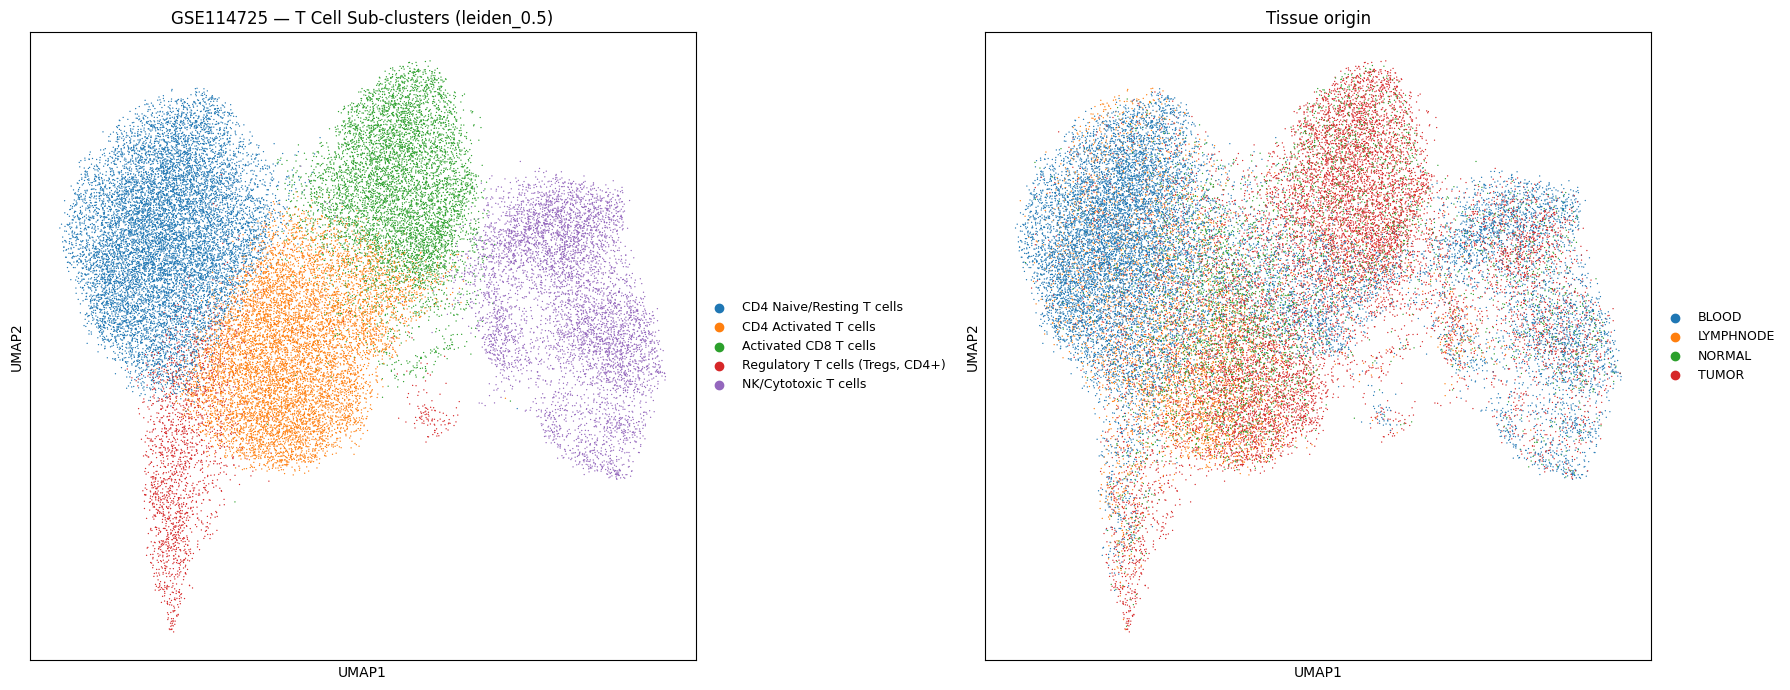

In [28]:
# ----------------------------
# Cell 12 — T cell marker genes and annotation
# Resolution 0.5 — 5 clusters, chosen over 0.7 after marker validation
# (0.7 fragments further without adding real biology; 0.5 already
# resolves a clean Treg population).
#
# CD4/CD8 lineage assignment: CD4 mRNA has well-documented high dropout
# in droplet scRNA-seq (low-abundance transcript), so lineage was
# determined primarily by CD8A/CD8B exclusion, with direct CD4 signal
# as supporting evidence rather than the sole criterion. Both lines of
# evidence agreed for every cluster (see canonical marker + CD4 check
# cells above).
# ----------------------------
sc.tl.rank_genes_groups(adata1_tcells, groupby="tcell_leiden_0.5",
                        method="wilcoxon", key_added="rank_genes_tcell")

tcell_markers = sc.get.rank_genes_groups_df(
    adata1_tcells, group=None, key="rank_genes_tcell")

print("T cell sub-cluster top 5 markers:")
for cl in sorted(tcell_markers["group"].unique(), key=lambda x: int(x)):
    genes = tcell_markers[tcell_markers["group"] == cl].head(5)["names"].tolist()
    n = adata1_tcells.obs["tcell_leiden_0.5"].value_counts()[cl]
    print(f"  Cluster {cl} (n={n}): {', '.join(genes)}")

# Labels based on canonical marker validation + CD4/CD8 exclusion check:
# C0: TCF7/CCR7/SELL highest, CD4=0.52 vs CD8A=0.22/CD8B=0.24 — CD4 naive/resting
# C1: CD69/FOS/JUN elevated, CD4=0.58 vs CD8A=0.21/CD8B=0.08 — CD4 activated
# C2: CD69 + CD8A=1.64/CD8B=0.92 (highest), CD4=0.13 — activated CD8
# C3: FOXP3/IL2RA/CTLA4/TIGIT dominant, CD4=0.80 (highest) vs CD8A=0.12/CD8B=0.07 — Tregs, CD4+
# C4: NKG7/GNLY/GZMB/PRF1 dominant, CD8A=0.79 vs CD4=0.10 — NK/Cytotoxic
tcell_labels = {
    "0": "CD4 Naive/Resting T cells",
    "1": "CD4 Activated T cells",
    "2": "Activated CD8 T cells",
    "3": "Regulatory T cells (Tregs, CD4+)",
    "4": "NK/Cytotoxic T cells",
}

adata1_tcells.obs["tcell_subtype"] = \
    adata1_tcells.obs["tcell_leiden_0.5"].map(tcell_labels)

n_unmapped = adata1_tcells.obs["tcell_subtype"].isna().sum()
if n_unmapped > 0:
    raise ValueError(f"{n_unmapped} T cells failed to map — check tcell_labels")

print("\nT cell subtype counts:")
print(adata1_tcells.obs["tcell_subtype"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sc.pl.umap(adata1_tcells, color="tcell_subtype",
           title="GSE114725 — T Cell Sub-clusters (leiden_0.5)",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata1_tcells, color="tissue",
           title="Tissue origin",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[1], show=False)

plt.tight_layout()

In [26]:
adata1_tcells_raw = adata1_tcells.raw.to_adata()
adata1_tcells_raw.obs["tcell_leiden_0.5"] = adata1_tcells.obs["tcell_leiden_0.5"].values

for gene in ["CD4", "CD3D", "CD3E", "CD8A", "CD8B"]:
    if gene in adata1_tcells_raw.var_names:
        vals = []
        for cl in sorted(adata1_tcells.obs["tcell_leiden_0.5"].unique(), key=int):
            mask = (adata1_tcells_raw.obs["tcell_leiden_0.5"] == cl).values
            X = adata1_tcells_raw[mask, gene].X
            if issparse(X): X = X.toarray()
            vals.append(f"C{cl}={X.mean():.2f}")
        print(f"{gene}: {', '.join(vals)}")

del adata1_tcells_raw
gc.collect()

CD4: C0=0.52, C1=0.58, C2=0.13, C3=0.80, C4=0.10
CD3D: C0=0.88, C1=0.87, C2=1.00, C3=1.04, C4=0.52
CD3E: C0=0.82, C1=0.81, C2=0.85, C3=0.82, C4=0.51
CD8A: C0=0.22, C1=0.21, C2=1.64, C3=0.12, C4=0.79
CD8B: C0=0.24, C1=0.08, C2=0.92, C3=0.07, C4=0.31


2995

In [24]:
# ----------------------------
# Cell 13 — Stretch 2: Macrophage sub-clustering (GSE114725)
# Motivated by: most DEGs in broad cluster DE, highest proportion in TNBC
# LAM-like and Antigen-presenting not cleanly separable at res 0.7
# — consistent with macrophage plasticity continuum (Azizi et al. 2018)
# Cytotoxic macrophage population (NKG7+) identified — tumour-enriched
# ----------------------------
adata1_mac = adata1[adata1.obs["cell_type"] == "Macrophages"].copy()

print(f"Macrophages extracted: {adata1_mac.n_obs} cells")
print(adata1_mac.obs["tissue"].value_counts())

sc.pp.neighbors(adata1_mac, use_rep="X_pca_harmony",
                n_neighbors=15, n_pcs=30, random_state=0)
sc.tl.umap(adata1_mac, random_state=42)

for res in [0.3, 0.5, 0.7]:
    sc.tl.leiden(adata1_mac, resolution=res,
                 key_added=f"mac_leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    print(f"Resolution {res}: "
          f"{adata1_mac.obs[f'mac_leiden_{res}'].nunique()} clusters")

Macrophages extracted: 5914 cells
tissue
TUMOR        4969
BLOOD         477
NORMAL        445
LYMPHNODE      23
Name: count, dtype: int64
Resolution 0.3: 7 clusters
Resolution 0.5: 8 clusters
Resolution 0.7: 9 clusters


In [25]:
adata1_mac_raw = adata1_mac.raw.to_adata()

mac_markers_screen = {
    "Resting/Resident": ["MRC1", "CD163", "FOLR2"],
    "LAM-like/Lipid": ["APOE", "FABP5", "TREM2", "SPP1"],
    "Antigen-presenting": ["HLA-DRA", "CD74", "HLA-DPB1"],
    "Cytotoxic/NK-like": ["NKG7", "GNLY", "GZMB"],
    "Monocyte-like": ["S100A8", "S100A9", "FCN1"],
    "Proliferating": ["STMN1", "MKI67", "TOP2A"],
    "Complement/classical": ["C1QA", "C1QB", "C1QC"],
}

for res_key in ["mac_leiden_0.3", "mac_leiden_0.5", "mac_leiden_0.7"]:
    n_clusters = adata1_mac.obs[res_key].nunique()
    print(f"\n{'='*50}")
    print(f"{res_key} — {n_clusters} clusters")
    print(f"{'='*50}")
    adata1_mac_raw.obs[res_key] = adata1_mac.obs[res_key].values
    for pop, genes in mac_markers_screen.items():
        print(f"\n  {pop}:")
        for gene in genes:
            if gene in adata1_mac_raw.var_names:
                vals = []
                for cl in sorted(adata1_mac.obs[res_key].unique(), key=int):
                    mask = (adata1_mac_raw.obs[res_key] == cl).values
                    X = adata1_mac_raw[mask, gene].X
                    if issparse(X): X = X.toarray()
                    vals.append(f"C{cl}={X.mean():.2f}")
                print(f"    {gene}: {', '.join(vals)}")
    sizes = adata1_mac.obs[res_key].value_counts().sort_index()
    print(f"\n  Cluster sizes: {dict(sizes)}")

del adata1_mac_raw
gc.collect()


mac_leiden_0.3 — 7 clusters

  Resting/Resident:
    MRC1: C0=0.18, C1=0.60, C2=1.41, C3=0.88, C4=0.27, C5=0.26, C6=0.03
    CD163: C0=0.52, C1=0.98, C2=1.68, C3=0.70, C4=1.20, C5=1.21, C6=0.05
    FOLR2: C0=0.09, C1=0.22, C2=1.43, C3=0.06, C4=0.40, C5=0.13, C6=0.02

  LAM-like/Lipid:
    APOE: C0=2.93, C1=4.14, C2=1.92, C3=0.42, C4=3.16, C5=0.58, C6=0.12
    FABP5: C0=0.44, C1=1.62, C2=0.24, C3=0.17, C4=0.47, C5=0.30, C6=0.01
    TREM2: C0=0.94, C1=2.09, C2=0.37, C3=0.22, C4=1.58, C5=0.38, C6=0.04
    SPP1: C0=2.98, C1=4.75, C2=0.66, C3=0.52, C4=1.75, C5=0.81, C6=0.13

  Antigen-presenting:
    HLA-DRA: C0=3.82, C1=3.45, C2=4.14, C3=5.23, C4=4.84, C5=3.96, C6=2.81
    CD74: C0=4.69, C1=4.25, C2=5.22, C3=5.79, C4=5.57, C5=4.68, C6=4.02
    HLA-DPB1: C0=2.17, C1=1.97, C2=2.87, C3=4.25, C4=3.52, C5=2.36, C6=1.64

  Cytotoxic/NK-like:
    NKG7: C0=0.10, C1=0.10, C2=0.15, C3=0.13, C4=0.11, C5=0.12, C6=0.08
    GNLY: C0=0.16, C1=0.07, C2=0.21, C3=0.15, C4=0.14, C5=0.19, C6=0.13
    GZMB: C

15281

In [29]:
# ----------------------------
# Cell 14 — Macrophage marker genes
# Resolution 0.5 — 8 clusters, chosen over 0.3 (missed the cytotoxic/
# NKG7+ population entirely) and 0.7 (fragmented LAM-like and
# Monocyte-like without adding real biology; cytotoxic cluster
# identical at 0.5 and 0.7, confirming it's stable, not resolution-
# dependent noise).
# ----------------------------
sc.tl.rank_genes_groups(adata1_mac, groupby="mac_leiden_0.5",
                        method="wilcoxon", key_added="rank_genes_mac")

mac_markers = sc.get.rank_genes_groups_df(
    adata1_mac, group=None, key="rank_genes_mac")

print("Macrophage sub-cluster top 5 markers:")
for cl in sorted(mac_markers["group"].unique(), key=lambda x: int(x)):
    genes = mac_markers[mac_markers["group"] == cl].head(5)["names"].tolist()
    n = adata1_mac.obs["mac_leiden_0.5"].value_counts()[cl]
    print(f"  Cluster {cl} (n={n}): {', '.join(genes)}")

Macrophage sub-cluster top 5 markers:
  Cluster 0 (n=946): SPP1, APOE, FTL, CTSD, CSTB
  Cluster 1 (n=735): LPL, CSTB, SPP1, CD9, ACP5
  Cluster 2 (n=910): HLA-DPB1, HLA-DRA, HLA-DPA1, HLA-DQB1, CD74
  Cluster 3 (n=1075): C3, C1QB, C1QA, C1QC, RGS1
  Cluster 4 (n=469): SEPP1, C1QA, RNASE1, C1QB, C1QC
  Cluster 5 (n=1265): VCAN, FCN1, LYZ, S100A9, S100A8
  Cluster 6 (n=423): LST1, FCGR3A, CDKN1C, NAP1L1, IFITM2
  Cluster 7 (n=91): DCN, COL1A1, MGP, IGFBP7, HBB


In [30]:
# ----------------------------
# Confirmation check — Cluster 7 (n=91): stromal/RBC contamination
# vs cytotoxic macrophage. Comparing the two candidate signatures
# directly, plus a check on overall QC metrics (contamination clusters
# often show unusual total_counts/n_genes profiles too).
# ----------------------------
adata1_mac_raw = adata1_mac.raw.to_adata()
adata1_mac_raw.obs["mac_leiden_0.5"] = adata1_mac.obs["mac_leiden_0.5"].values

print("=== Cytotoxic/NK signature ===")
for gene in ["NKG7", "GNLY", "GZMB", "PRF1", "KLRD1"]:
    if gene in adata1_mac_raw.var_names:
        mask7 = (adata1_mac_raw.obs["mac_leiden_0.5"] == "7").values
        mask_other = (adata1_mac_raw.obs["mac_leiden_0.5"] != "7").values
        X7 = adata1_mac_raw[mask7, gene].X
        Xother = adata1_mac_raw[mask_other, gene].X
        if issparse(X7): X7 = X7.toarray()
        if issparse(Xother): Xother = Xother.toarray()
        print(f"  {gene}: C7={X7.mean():.2f}, all other macrophage clusters={Xother.mean():.2f}")

print("\n=== Stromal/RBC signature ===")
for gene in ["COL1A1", "DCN", "MGP", "HBB", "HBA1", "PDGFRB"]:
    if gene in adata1_mac_raw.var_names:
        mask7 = (adata1_mac_raw.obs["mac_leiden_0.5"] == "7").values
        mask_other = (adata1_mac_raw.obs["mac_leiden_0.5"] != "7").values
        X7 = adata1_mac_raw[mask7, gene].X
        Xother = adata1_mac_raw[mask_other, gene].X
        if issparse(X7): X7 = X7.toarray()
        if issparse(Xother): Xother = Xother.toarray()
        print(f"  {gene}: C7={X7.mean():.2f}, all other macrophage clusters={Xother.mean():.2f}")

print("\n=== Macrophage/myeloid identity check (should this even BE in the macrophage cluster?) ===")
for gene in ["CD68", "LYZ", "PTPRC"]:  # PTPRC = CD45, pan-immune marker
    if gene in adata1_mac_raw.var_names:
        mask7 = (adata1_mac_raw.obs["mac_leiden_0.5"] == "7").values
        mask_other = (adata1_mac_raw.obs["mac_leiden_0.5"] != "7").values
        X7 = adata1_mac_raw[mask7, gene].X
        Xother = adata1_mac_raw[mask_other, gene].X
        if issparse(X7): X7 = X7.toarray()
        if issparse(Xother): Xother = Xother.toarray()
        print(f"  {gene}: C7={X7.mean():.2f}, all other macrophage clusters={Xother.mean():.2f}")

print("\n=== QC metrics — contamination clusters often show unusual profiles ===")
qc_c7 = adata1_mac.obs.loc[adata1_mac.obs["mac_leiden_0.5"] == "7", ["n_genes_by_counts", "total_counts"]]
qc_other = adata1_mac.obs.loc[adata1_mac.obs["mac_leiden_0.5"] != "7", ["n_genes_by_counts", "total_counts"]]
print(f"  C7 mean n_genes: {qc_c7['n_genes_by_counts'].mean():.0f}, mean total_counts: {qc_c7['total_counts'].mean():.0f}")
print(f"  Other clusters mean n_genes: {qc_other['n_genes_by_counts'].mean():.0f}, mean total_counts: {qc_other['total_counts'].mean():.0f}")

del adata1_mac_raw
gc.collect()

=== Cytotoxic/NK signature ===
  NKG7: C7=0.54, all other macrophage clusters=0.11
  GNLY: C7=0.78, all other macrophage clusters=0.14
  GZMB: C7=0.31, all other macrophage clusters=0.09
  PRF1: C7=0.86, all other macrophage clusters=0.11
  KLRD1: C7=0.70, all other macrophage clusters=0.08

=== Stromal/RBC signature ===
  COL1A1: C7=3.36, all other macrophage clusters=0.20
  DCN: C7=2.72, all other macrophage clusters=0.08
  MGP: C7=2.58, all other macrophage clusters=0.12
  HBB: C7=2.02, all other macrophage clusters=0.04
  HBA1: C7=0.07, all other macrophage clusters=0.00
  PDGFRB: C7=0.53, all other macrophage clusters=0.01

=== Macrophage/myeloid identity check (should this even BE in the macrophage cluster?) ===
  CD68: C7=1.25, all other macrophage clusters=2.07
  LYZ: C7=2.04, all other macrophage clusters=3.17
  PTPRC: C7=1.48, all other macrophage clusters=1.09

=== QC metrics — contamination clusters often show unusual profiles ===
  C7 mean n_genes: 2059, mean total_counts:

15743

In [31]:
mac_labels = {
    "0": "LAM-like macrophages",
    "1": "Lipid-laden/Foam-cell macrophages",
    "2": "Antigen-presenting macrophages",
    "3": "Complement-high macrophages",
    "4": "Resting/Resident macrophages",
    "5": "Monocyte-like macrophages",
    "6": "Non-classical monocytes (CD16+)",
    "7": "Unassigned (n=91, stromal/RBC contamination artefact)",
}

In [32]:
adata1_mac.obs["mac_subtype"] = \
    adata1_mac.obs["mac_leiden_0.5"].map(mac_labels)

n_unmapped = adata1_mac.obs["mac_subtype"].isna().sum()
if n_unmapped > 0:
    raise ValueError(f"{n_unmapped} macrophages failed to map — check mac_labels")

print("Macrophage subtype counts:")
print(adata1_mac.obs["mac_subtype"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sc.pl.umap(adata1_mac, color="mac_subtype",
           title="GSE114725 — Macrophage Sub-clusters (leiden_0.5)",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata1_mac, color="tissue",
           title="Tissue origin",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_macrophage_subclusters_umap.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

mac_markers.groupby("group").head(10).to_csv(
    RESULTS_DIR / "GSE114725_macrophage_subcluster_markers.csv", index=False)
adata1_mac.write(
    PROCESSED_DIR / "GSE114725_macrophages_subclustered.h5ad",
    compression="gzip")
print("\nSaved macrophage sub-clustered object")

Macrophage subtype counts:
mac_subtype
Monocyte-like macrophages                                1265
Complement-high macrophages                              1075
LAM-like macrophages                                      946
Antigen-presenting macrophages                            910
Lipid-laden/Foam-cell macrophages                         735
Resting/Resident macrophages                              469
Non-classical monocytes (CD16+)                           423
Unassigned (n=91, stromal/RBC contamination artefact)      91
Name: count, dtype: int64

Saved macrophage sub-clustered object


**Note:** earlier drafts of this notebook included a separate monocyte/DC (cluster 5) sub-clustering step here, built to resolve an ambiguity between clusters 3 and 5 at the old resolution 0.6. That ambiguity no longer exists at the corrected resolution 0.2 — clusters 5 (Macrophages) and 7 (Monocytes/DC) are both clean, canonically distinct populations (see validation cells above), so this step was removed rather than kept as dead investigative code.

In [1]:
import gc
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase2_clustering_v2"
RESULTS_DIR = PROJECT_DIR / "results" / "phase2_clustering_v2"

adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad")
print(f"GSE114725 reloaded: {adata1.n_obs} cells, cell_type present: {'cell_type' in adata1.obs.columns}")

GSE114725 reloaded: 44662 cells, cell_type present: True


In [3]:
adata2 = sc.read_h5ad(
    PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad",
    backed="r"
)
print(f"GSE176078 reloaded: {adata2.n_obs} cells, cell_type present: {'cell_type' in adata2.obs.columns}")
print(adata2.obs["cell_type"].value_counts())

GSE176078 reloaded: 91425 cells, cell_type present: True
cell_type
Luminal epithelial                                    19084
CD8 T cells                                           10916
Memory T cells                                         9112
Macrophages                                            8716
Endothelial cells                                      7040
CAFs                                                   6469
T cells                                                6467
PVL                                                    5033
Epithelial (ambiguous)                                 4923
NK cells                                               3083
B cells                                                2786
Cycling epithelial                                     2774
Plasma cells                                           2615
Basal epithelial                                       1073
Cycling T cells                                         991
pDC                              

In [5]:
# GSE114725 — per patient
props1 = adata1.obs.groupby(
    ["patient", "cell_type"]).size().unstack(fill_value=0)
props1_pct = props1.div(props1.sum(axis=1), axis=0) * 100
props1_pct.to_csv(RESULTS_DIR / "GSE114725_celltype_proportions.csv")

fig, ax = plt.subplots(figsize=(12, 6))
props1_pct.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("Patient")
ax.set_ylabel("Proportion (%)")
ax.set_title("GSE114725 — Cell Type Proportions per Patient")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_celltype_proportions.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

# GSE176078 — per subtype
props2 = adata2.obs.groupby(
    ["subtype", "cell_type"]).size().unstack(fill_value=0)
props2_pct = props2.div(props2.sum(axis=1), axis=0) * 100
props2_pct.to_csv(RESULTS_DIR / "GSE176078_celltype_proportions_by_subtype.csv")

fig, ax = plt.subplots(figsize=(12, 7))
props2_pct.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("Subtype")
ax.set_ylabel("Proportion (%)")
ax.set_title("GSE176078 — Cell Type Proportions by Breast Cancer Subtype")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_celltype_proportions_subtype.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

print("GSE114725 proportions:")
print(props1_pct.round(1))
print("\nGSE176078 proportions:")
print(props2_pct.round(1))

C:\Users\annam\AppData\Local\Temp\ipykernel_9256\4222762620.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  props1 = adata1.obs.groupby(
C:\Users\annam\AppData\Local\Temp\ipykernel_9256\4222762620.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  props2 = adata2.obs.groupby(


GSE114725 proportions:
cell_type  T cells  CD8/Effector T cells  \
patient                                    
BC1           55.1                  20.0   
BC2           56.7                  18.9   
BC3            4.4                   9.7   
BC4           51.4                  13.6   
BC5           29.9                  25.0   
BC6           14.4                  19.4   
BC7           23.9                  18.3   
BC8           19.4                  30.9   

cell_type  Mixed/stromal-contaminated (CD8+fibroblast signal)  \
patient                                                         
BC1                                                      0.1    
BC2                                                      0.2    
BC3                                                      2.8    
BC4                                                      6.6    
BC5                                                      0.2    
BC6                                                      0.2    
BC7             

In [6]:
# ----------------------------
# NEW — Statistical tests on cell-type proportions
# GSE114725: tumour vs blood, paired by patient (Wilcoxon signed-rank)
# GSE176078: ER+/HER2+/TNBC, unpaired (Kruskal-Wallis, 3 groups)
# Benjamini-Hochberg FDR correction applied within each dataset since
# multiple cell types are being tested simultaneously.
# ----------------------------
from scipy.stats import wilcoxon, kruskal
from statsmodels.stats.multitest import multipletests

# --- GSE114725: tumour vs blood, paired by patient ---
props1_by_tissue = adata1.obs.groupby(
    ["patient", "tissue", "cell_type"]).size().unstack(fill_value=0)
props1_by_tissue_pct = props1_by_tissue.div(props1_by_tissue.sum(axis=1), axis=0) * 100

results1 = []
for ct in props1_by_tissue_pct.columns:
    df = props1_by_tissue_pct[ct].reset_index()
    pivot = df.pivot(index="patient", columns="tissue", values=ct)
    # only patients with BOTH tumour and blood samples
    paired = pivot[["TUMOR", "BLOOD"]].dropna()
    if len(paired) < 3:
        continue
    stat, p = wilcoxon(paired["TUMOR"], paired["BLOOD"])
    results1.append({
        "cell_type": ct, "n_paired_patients": len(paired),
        "mean_tumor_pct": paired["TUMOR"].mean(),
        "mean_blood_pct": paired["BLOOD"].mean(),
        "p_value": p
    })

results1_df = pd.DataFrame(results1)
results1_df["fdr"] = multipletests(results1_df["p_value"], method="fdr_bh")[1]
results1_df = results1_df.sort_values("fdr")
results1_df.to_csv(RESULTS_DIR / "GSE114725_proportion_stats_tumor_vs_blood.csv", index=False)
print("=== GSE114725: Tumour vs Blood (paired Wilcoxon) ===")
print(results1_df.to_string(index=False))

# --- GSE176078: ER+/HER2+/TNBC, unpaired Kruskal-Wallis ---
props2_by_subtype = adata2.obs.groupby(
    ["subtype", "cell_type"]).size().unstack(fill_value=0)
# Need per-SAMPLE (not aggregated per-subtype) proportions for a real test —
# aggregate subtype-level percentages (what you already have) can't be
# tested statistically, since there's no within-group variance to test against.
props2_by_sample = adata2.obs.groupby(
    ["orig.ident", "subtype", "cell_type"]).size().unstack(fill_value=0)
props2_by_sample_pct = props2_by_sample.div(props2_by_sample.sum(axis=1), axis=0) * 100
props2_by_sample_pct = props2_by_sample_pct.reset_index()

results2 = []
for ct in adata2.obs["cell_type"].unique():
    if ct not in props2_by_sample_pct.columns:
        continue
    groups = [
        props2_by_sample_pct.loc[props2_by_sample_pct["subtype"] == s, ct].dropna()
        for s in ["ER+", "HER2+", "TNBC"]
    ]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        continue
    stat, p = kruskal(*groups)
    results2.append({"cell_type": ct, "n_samples_per_group": [len(g) for g in groups], "p_value": p})

results2_df = pd.DataFrame(results2)
results2_df["fdr"] = multipletests(results2_df["p_value"], method="fdr_bh")[1]
results2_df = results2_df.sort_values("fdr")
results2_df.to_csv(RESULTS_DIR / "GSE176078_proportion_stats_by_subtype.csv", index=False)
print("\n=== GSE176078: ER+/HER2+/TNBC (Kruskal-Wallis) ===")
print(results2_df.to_string(index=False))

C:\Users\annam\AppData\Local\Temp\ipykernel_9256\115850001.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  props1_by_tissue = adata1.obs.groupby(


KeyError: 'p_value'

In [8]:
# Diagnostic first — sample sizes per subtype, before trusting any test
sample_counts = adata2.obs.groupby("subtype", observed=True)["orig.ident"].nunique()
print("Samples per subtype:")
print(sample_counts)

Samples per subtype:
subtype
ER+      11
HER2+     5
TNBC     10
Name: orig.ident, dtype: int64


In [9]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

# Per-SAMPLE (not aggregated per-subtype) proportions — needed for a real
# test, since aggregate subtype-level percentages have no within-group
# variance to test against.
props2_by_sample = adata2.obs.groupby(
    ["orig.ident", "subtype", "cell_type"], observed=True).size().unstack(fill_value=0)
props2_by_sample_pct = props2_by_sample.div(props2_by_sample.sum(axis=1), axis=0) * 100
props2_by_sample_pct = props2_by_sample_pct.reset_index()

results2 = []
for ct in adata2.obs["cell_type"].unique():
    if ct not in props2_by_sample_pct.columns:
        continue
    groups = [
        props2_by_sample_pct.loc[props2_by_sample_pct["subtype"] == s, ct].dropna()
        for s in ["ER+", "HER2+", "TNBC"]
    ]
    n_per_group = [len(g) for g in groups]
    if any(n < 2 for n in n_per_group):
        continue
    stat, p = kruskal(*groups)
    results2.append({
        "cell_type": ct,
        "n_ER": n_per_group[0], "n_HER2": n_per_group[1], "n_TNBC": n_per_group[2],
        "mean_ER_pct": groups[0].mean(), "mean_HER2_pct": groups[1].mean(), "mean_TNBC_pct": groups[2].mean(),
        "p_value": p
    })

results2_df = pd.DataFrame(results2)
results2_df["fdr"] = multipletests(results2_df["p_value"], method="fdr_bh")[1]
results2_df = results2_df.sort_values("fdr")
results2_df.to_csv(RESULTS_DIR / "GSE176078_proportion_stats_by_subtype.csv", index=False)

print("=== GSE176078: ER+/HER2+/TNBC cell-type proportions (Kruskal-Wallis, n=11/5/10 samples) ===")
print(results2_df.round(4).to_string(index=False))
print(f"\nSignificant at FDR < 0.05: {(results2_df['fdr'] < 0.05).sum()} of {len(results2_df)} cell types tested")

=== GSE176078: ER+/HER2+/TNBC cell-type proportions (Kruskal-Wallis, n=11/5/10 samples) ===
                                         cell_type  n_ER  n_HER2  n_TNBC  mean_ER_pct  mean_HER2_pct  mean_TNBC_pct  p_value    fdr
                                 Endothelial cells    11       5      10      10.7216         4.9520         5.4075   0.0567 0.2085
                                   Cycling T cells    11       5      10       0.3703         0.5985         1.4329   0.0709 0.2085
                                           T cells    11       5      10       5.8112        12.1506         5.1428   0.0736 0.2085
                                Luminal epithelial    11       5      10      38.3650        10.0731        11.9037   0.0542 0.2085
                                       Macrophages    11       5      10       5.2554         8.9510        14.6631   0.0304 0.2085
                                    Memory T cells    11       5      10       7.6608        19.1557         7.0279 

In [7]:
# Diagnostic — how many patients actually have BOTH tumour and blood samples?
tissue_by_patient = adata1.obs.groupby(["patient", "tissue"], observed=True).size().unstack(fill_value=0)
print(tissue_by_patient)
print("\nPatients with both TUMOR and BLOOD samples:")
has_both = (tissue_by_patient["TUMOR"] > 0) & (tissue_by_patient["BLOOD"] > 0)
print(tissue_by_patient[has_both].index.tolist())
print(f"Count: {has_both.sum()}")

tissue   BLOOD  LYMPHNODE  NORMAL  TUMOR
patient                                 
BC1       2736          0    2750   1366
BC2          0       5136    1157   1912
BC3          0          0     249    647
BC4      12856          0       0   6133
BC5          0          0       0   1764
BC6          0          0       0   3497
BC7          0          0     184   1679
BC8          0          0       0   2596

Patients with both TUMOR and BLOOD samples:
['BC1', 'BC4']
Count: 2


In [10]:
# ----------------------------
# Cell 16 — Stretch 4: Reference atlas comparison (GSE176078)
# Cross-tabulate our annotations vs Wu et al. 2021 published labels
# Only possible for GSE176078 — GSE114725 has no published per-cell annotations
# ----------------------------
comparison = pd.crosstab(
    adata2.obs["cell_type"],
    adata2.obs["celltype_major"],
    normalize="index"
).round(3) * 100

comparison.to_csv(RESULTS_DIR / "GSE176078_our_vs_published_comparison.csv")

print("Our annotation vs Wu et al. 2021 published labels (%):")
print(comparison)

print("\nTop concordance per cell type:")
for ct in comparison.index:
    top = comparison.loc[ct].idxmax()
    pct = comparison.loc[ct].max()
    print(f"  {ct} -> {top}: {pct:.1f}%")

Our annotation vs Wu et al. 2021 published labels (%):
celltype_major                                      B-cells  CAFs  \
cell_type                                                           
B cells                                                96.9   0.0   
Basal epithelial                                        0.0   0.1   
CAFs                                                    0.0  89.3   
CD8 T cells                                             0.0   0.0   
Cycling T cells                                         0.0   0.0   
Cycling epithelial                                      0.0   0.0   
Endothelial cells                                       0.0   0.0   
Epithelial (ambiguous)                                  0.0   0.1   
Luminal epithelial                                      0.0   0.0   
Macrophages                                             0.5   0.1   
Memory T cells                                          0.1   0.0   
NK cells                                        

In [11]:
import scanpy as sc
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"

adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad", backed="r")

print("Patient x Tissue cell counts:")
print(adata1.obs.groupby(["patient", "tissue"], observed=True).size().unstack(fill_value=0))

print("\nPatients per tissue type (for pseudobulk group sizes):")
tissue_patient_counts = adata1.obs.groupby("tissue", observed=True)["patient"].nunique()
print(tissue_patient_counts)

print("\nCell type x Tissue breakdown (needed since pseudobulk DE is done WITHIN each cell type):")
print(adata1.obs.groupby(["cell_type", "tissue"], observed=True).size().unstack(fill_value=0))

Patient x Tissue cell counts:
tissue   BLOOD  LYMPHNODE  NORMAL  TUMOR
patient                                 
BC1       2736          0    2750   1366
BC2          0       5136    1157   1912
BC3          0          0     249    647
BC4      12856          0       0   6133
BC5          0          0       0   1764
BC6          0          0       0   3497
BC7          0          0     184   1679
BC8          0          0       0   2596

Patients per tissue type (for pseudobulk group sizes):
tissue
BLOOD        2
LYMPHNODE    1
NORMAL       4
TUMOR        8
Name: patient, dtype: int64

Cell type x Tissue breakdown (needed since pseudobulk DE is done WITHIN each cell type):
tissue                                              BLOOD  LYMPHNODE  NORMAL  \
cell_type                                                                      
T cells                                             10017       3591    2051   
CD8/Effector T cells                                  879        247    1180   

In [12]:
# ----------------------------
# Per-patient, per-cell-type cell counts for TUMOR and NORMAL specifically —
# determines which cell types have enough cells per patient to support
# reliable pseudobulk aggregation (a pseudobulk "sample" built from very
# few cells is noisy regardless of how many patients contribute one).
# ----------------------------
MIN_CELLS_PER_PSEUDOBULK_SAMPLE = 10  # common rule-of-thumb floor; below this,
                                        # a single patient's pseudobulk profile
                                        # is dominated by a handful of cells

for tissue in ["TUMOR", "NORMAL"]:
    print(f"\n{'='*60}")
    print(f"{tissue} — cells per patient per cell type")
    print(f"{'='*60}")
    subset = adata1.obs[adata1.obs["tissue"] == tissue]
    counts = subset.groupby(["cell_type", "patient"], observed=True).size().unstack(fill_value=0)
    print(counts)

print(f"\n{'='*60}")
print(f"SUMMARY: cell types with >={MIN_CELLS_PER_PSEUDOBULK_SAMPLE} cells in")
print(f"BOTH tumour and normal, in enough patients to be usable")
print(f"{'='*60}")

tumor_subset = adata1.obs[adata1.obs["tissue"] == "TUMOR"]
normal_subset = adata1.obs[adata1.obs["tissue"] == "NORMAL"]

tumor_counts = tumor_subset.groupby(["cell_type", "patient"], observed=True).size().unstack(fill_value=0)
normal_counts = normal_subset.groupby(["cell_type", "patient"], observed=True).size().unstack(fill_value=0)

for ct in adata1.obs["cell_type"].unique():
    if ct not in tumor_counts.index or ct not in normal_counts.index:
        print(f"  {ct}: MISSING from one tissue entirely — cannot compare")
        continue
    n_tumor_viable = (tumor_counts.loc[ct] >= MIN_CELLS_PER_PSEUDOBULK_SAMPLE).sum()
    n_normal_viable = (normal_counts.loc[ct] >= MIN_CELLS_PER_PSEUDOBULK_SAMPLE).sum()
    status = "OK" if (n_tumor_viable >= 3 and n_normal_viable >= 3) else "INSUFFICIENT"
    print(f"  {ct}: {n_tumor_viable} tumour patients viable, {n_normal_viable} normal patients viable -> {status}")


TUMOR — cells per patient per cell type
patient                                             BC1   BC2  BC3   BC4  BC5  \
cell_type                                                                       
T cells                                             462   682   32  1447  527   
CD8/Effector T cells                                463  1000   63  1793  441   
Mixed/stromal-contaminated (CD8+fibroblast signal)    3    11    8  1254    3   
NK/Cytotoxic T cells                                 37   101   52   714  149   
B cells                                             154    27   69    89  171   
Macrophages                                         233    87  407   507  436   
pDC                                                   1     0    6    11   15   
Monocytes/DC                                          0     2    5    87    9   
Mast cells                                           13     2    5   231   13   

patient                                              BC6  BC7   BC8

In [13]:
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad", backed="r")

MIN_CELLS_PER_PSEUDOBULK_SAMPLE = 10

print("Samples per subtype (already known: 11/5/10 for ER+/HER2+/TNBC):")
print(adata2.obs.groupby("subtype", observed=True)["orig.ident"].nunique())

print("\n" + "="*70)
print("Per-sample, per-cell-type cell counts, split by subtype")
print("="*70)

subtype_sample_counts = {}
for subtype in ["ER+", "HER2+", "TNBC"]:
    subset = adata2.obs[adata2.obs["subtype"] == subtype]
    counts = subset.groupby(["cell_type", "orig.ident"], observed=True).size().unstack(fill_value=0)
    subtype_sample_counts[subtype] = counts

print("\n" + "="*70)
print(f"SUMMARY: cell types with >={MIN_CELLS_PER_PSEUDOBULK_SAMPLE} cells in")
print(f"enough samples per subtype (need >=3 samples/subtype minimum)")
print("="*70)

all_cell_types = adata2.obs["cell_type"].unique()
for ct in all_cell_types:
    row = f"  {ct}: "
    viable_counts = []
    for subtype in ["ER+", "HER2+", "TNBC"]:
        counts = subtype_sample_counts[subtype]
        if ct in counts.index:
            n_viable = (counts.loc[ct] >= MIN_CELLS_PER_PSEUDOBULK_SAMPLE).sum()
        else:
            n_viable = 0
        viable_counts.append(n_viable)
    status = "OK" if all(n >= 3 for n in viable_counts) else "INSUFFICIENT"
    print(f"{row}ER+={viable_counts[0]}, HER2+={viable_counts[1]}, TNBC={viable_counts[2]} -> {status}")

Samples per subtype (already known: 11/5/10 for ER+/HER2+/TNBC):
subtype
ER+      11
HER2+     5
TNBC     10
Name: orig.ident, dtype: int64

Per-sample, per-cell-type cell counts, split by subtype

SUMMARY: cell types with >=10 cells in
enough samples per subtype (need >=3 samples/subtype minimum)
  Endothelial cells: ER+=11, HER2+=5, TNBC=9 -> OK
  CAFs: ER+=10, HER2+=5, TNBC=10 -> OK
  PVL: ER+=10, HER2+=5, TNBC=9 -> OK
  Basal epithelial: ER+=2, HER2+=2, TNBC=3 -> INSUFFICIENT
  B cells: ER+=8, HER2+=5, TNBC=5 -> OK
  Plasma cells: ER+=7, HER2+=2, TNBC=5 -> INSUFFICIENT
  CD8 T cells: ER+=10, HER2+=5, TNBC=8 -> OK
  NK cells: ER+=10, HER2+=5, TNBC=8 -> OK
  Memory T cells: ER+=10, HER2+=5, TNBC=8 -> OK
  T cells: ER+=10, HER2+=5, TNBC=8 -> OK
  Cycling T cells: ER+=2, HER2+=5, TNBC=6 -> INSUFFICIENT
  Cycling epithelial: ER+=7, HER2+=3, TNBC=8 -> OK
  Macrophages: ER+=11, HER2+=5, TNBC=10 -> OK
  pDC: ER+=2, HER2+=2, TNBC=3 -> INSUFFICIENT
  Epithelial (ambiguous): ER+=6, HER2+=4, T